## References

- https://plotly.com/python/axes/
- https://dash.plotly.com/
- https://plotly.com/python/bar-charts/

# SK & RA Code

Minutes Data Head:
Minutes dataset attribute data types:
Id               int64
ActivityHour    object
Steps00          int64
Steps01          int64
Steps02          int64
                 ...  
Steps55          int64
Steps56          int64
Steps57          int64
Steps58          int64
Steps59          int64
Length: 62, dtype: object
Minutes dataset dimensions:
(21645, 62)
Number of N/A values:
             Id       Date  DayTotal
0    1503960366 2016-04-13     10735
1    1503960366 2016-04-14     10460
2    1503960366 2016-04-15      9685
3    1503960366 2016-04-16     12669
4    1503960366 2016-04-17      9705
..          ...        ...       ...
914  8877689391 2016-05-09     20156
915  8877689391 2016-05-10     10693
916  8877689391 2016-05-11     21391
917  8877689391 2016-05-12     16530
918  8877689391 2016-05-13      1148

[919 rows x 3 columns]
Number of users with enough valid data: 29
Number of users in dataset: 33


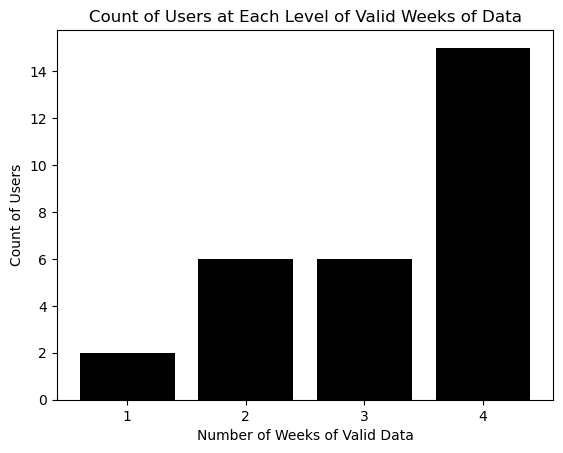

In [1]:
# Start date: 13/10/2024
# Author: SK

# Load relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read in minute-by-minute step counts data file
minutes_og = pd.read_csv("data/minuteStepsWide_merged.csv")

# Copy data frame to preserve original data
minutes = minutes_og.copy()

# Inspect head of each dataset
print("Minutes Data Head:")
minutes.head()

# End date: XXXX

# Start date: 13/10/2024
# Author: SK

# Check data types in data frame
print("Minutes dataset attribute data types:")
print(minutes.dtypes)

# Check dimensions of data frame
print("Minutes dataset dimensions:")
print(minutes.shape)

# End date: XXXX

# Start date: 13/10/2024
# Author: SK

# Create a new 'Date' column from the 'ActivityHour' column using string splitting
minutes['Date'] = minutes.ActivityHour.str.split('\s+').str[0]

# Converting the 'ActivityHour' and 'Date' columns to 'datetime' types
minutes['ActivityHour'] = pd.to_datetime(minutes['ActivityHour'], errors = 'coerce')
minutes['Date'] = pd.to_datetime(minutes['Date'], format = '%m/%d/%Y')

# Check conversions were succesful
minutes.dtypes

# End date: XXXX

# Start date: 13/10/2024
# Author: SK

# Sum the number of appearances of N/A values per row and then down all rows
print("Number of N/A values:")
minutes.isna().sum(axis = 1).sum()

# End date: xxxx

# Start date: 13/10/2024
# Author: SK

# Subset columns to only the hourly step counts columns
colnames = list(minutes.columns.values)
minutes['HourTotal'] = minutes.loc[:,colnames[2:-1]].sum(axis=1)

# Sum the total number of steps per day
minutes_agg = minutes.groupby(['Id', 'Date']).sum('HourTotal').reset_index().rename(columns = {"HourTotal": "DayTotal"})
minutes_agg = minutes_agg[['Id', 'Date', 'DayTotal']]

# Check summation of steps per day (for each ID) was successful

print(minutes_agg)
# End date: XXXX

# Start date: 13/10/2024
# Author: SK

def week_finder(df, datelist): # function for collecting valid dates into 'weeks' for a single user's minutes data
    weeks_nest_list = []
    week_list = []
    # Create a list of 'weeks' in which 7 contiguous dates are stored as a list if each day is valid
    for i in range(0, (len(datelist) - 1)): # iterate through all the days' step counts
        if df.loc[i, 'DayTotal'] > 500:
            week_list.append(datelist[i]) # adding valid date to the list
        else: # checking if the list of dates forms a week or not
            if len(week_list) < 7: # if an invalid day is reached before a week of data is stored, days are discarded
                week_list = []
            elif len(week_list) == 7: # storing a week of data
                weeks_nest_list.append(week_list)
                week_list = [] 
    
        if len(week_list) == 7: # storing a week of data
            weeks_nest_list.append(week_list)
            week_list = []     
        i = i + 1
        
    return weeks_nest_list

# Create dictionary to store every Id with enough data and the dates with valid data
user_valid_weeks_dict = {}

# Iterate through every ID in the dataset to determine if there is enough valid data, and if so to store this data
for x in list(minutes_agg.Id.unique()):
    minutes_agg_filt = minutes_agg.loc[minutes_agg['Id'].isin([x])].reset_index()
    date_list = list(minutes_agg_filt.Date) 
    id_valid_weeks_list = week_finder(minutes_agg_filt, date_list)
    if len(id_valid_weeks_list) > 0:
        user_valid_weeks_dict[x] = id_valid_weeks_list


# Compare number of IDs with valid data to number of IDs in original dataset
print("Number of users with enough valid data:", len(user_valid_weeks_dict.keys()))
print("Number of users in dataset:", len(minutes_agg.Id.unique()))

# Print IDs with valid amount of data - probably not needed so could cut this?
# Commenting out for now
#print('Users with at least one week of valid days of data:')
#for x in user_valid_weeks_dict.keys():
    #print(x)

# Start date: 13/10/2024
# Author: SK

user_valid_data_dict = {}

for x in user_valid_weeks_dict.keys(): # examine dataset of each user
    df_of_weeks_list = []
    week_list = user_valid_weeks_dict[x]
    minutes_filtered = minutes.loc[minutes['Id'].isin([x])].reset_index()
    for week in week_list: # for each 'week' of dates, select the relevant rows in the user's data frame 
        # append the user's list of data frames with a new filtered data frame just containing a certain week's data
        df_of_weeks_list.append(minutes_filtered.loc[minutes_filtered['Date'].isin(week)].reset_index().drop(['level_0', 'index'], axis=1))
    user_valid_data_dict[x] = df_of_weeks_list # assign the list of weekly data frames to the user ID in the dictionary

###
# COPY ALL CODE ABOVE THIS COMMENT TO ENSURE YOU HAVE THE FULL DICTIONARY OF WEEKLY DATA FRAMES FOR EACH USER
###
    
weeks_count_per_id = []
for x in user_valid_data_dict.keys(): # pretty print number of weekly data frames present for each user
    weeks_count_per_id.append(len(user_valid_data_dict[x]))
    #print("User ID:", x)
    #print("Number of weekly data frames:", len(user_valid_data_dict[x]))
    
# Visualise the amount of weeks of data per user with a barplot
weeks_count_per_id = pd.DataFrame({'Weeks':weeks_count_per_id, 'Count': [1]*len(weeks_count_per_id)})
weeks_count_agg = weeks_count_per_id.groupby('Weeks').sum().reset_index()
plt.bar(weeks_count_agg['Weeks'], weeks_count_agg['Count'], color = 'black')
plt.xticks(weeks_count_agg['Weeks'])
plt.xlabel("Number of Weeks of Valid Data")
plt.ylabel("Count of Users")
plt.title("Count of Users at Each Level of Valid Weeks of Data")
# End date: XXXX

# Start date: 13/10/2024
# Author: SK

#start and end date: 16/10/2024
#Author: RA

#to measure these variables, the scipy.stats module must be imported
from scipy.stats import skew, kurtosis

user_valid_data_dict = {}

for x in user_valid_weeks_dict.keys(): # examine dataset of each user
    df_of_weeks_list = []
    week_list = user_valid_weeks_dict[x]
    minutes_filtered = minutes.loc[minutes['Id'].isin([x])].reset_index()
    for week in week_list: # for each 'week' of dates, select the relevant rows in the user's data frame 
        # append the user's list of data frames with a new filtered data frame just containing a certain week's data
        df_of_weeks_list.append(minutes_filtered.loc[minutes_filtered['Date'].isin(week)].reset_index().drop(['level_0', 'index'], axis=1))
    user_valid_data_dict[x] = df_of_weeks_list # assign the list of weekly data frames to the user ID in the dictionary

#start and end date: 16/10/2024
#Author: RA

#First the valid days must be extracted from the nested lists in the user_valid_weeks_dict dictionary.

# Create a new dictionary to store the flattened days for each user
user_days_dict = {}


for user_id, weeks in user_valid_weeks_dict.items():
    # Flatten the list of weeks into a single list of days
    #for each user, make a list of days. extract from week in weeks, and day is defined as elements of weeks list
    all_days_for_user = [day for week in weeks for day in week]
    
    #Assign the flattened list as the value for user_days_dict
    user_days_dict[user_id] = all_days_for_user
    
#start and end date: 16/10/2024
#Author: RA

#initialise a list
ID_features_daily = []


#loop through the valid ID's and evaluate their features
for ID in user_valid_data_dict:
    #first filter the data in minutes agg dataset
    user_data = minutes_agg[minutes_agg['Id'] == ID]
    #after obtaining the correct ID's now the correct dates are needed.
    valid_days = user_days_dict.get(ID, [])
    #finally need to change user_data to operate on correct dates as well
    user_data = user_data[user_data['Date'].isin(valid_days)]
    
    #then calculate the statistics required
    user_mean = round(user_data['DayTotal'].mean(), 0) #calculate the mean daily steps
    user_min = round(user_data['DayTotal'].min(), 0) #calculate the minimum daily steps
    user_max = round(user_data['DayTotal'].max(), 0) #calculate the maximum daily steps
    user_median = round(user_data['DayTotal'].median(), 0) #calculate the median daily steps
    user_std = round(user_data['DayTotal'].std(), 0) #calculate the standard deviation of the daily steps 
    #then calculate the two more complex variables: skewness and kurtosis.
    user_skewness = round(skew(user_data['DayTotal']), 0)
    user_kurtosis = round(kurtosis(user_data['DayTotal']), 0)
    
    #next, create a dictionary of features for the required statistics
    features = {
        'Id': ID,
        'Mean_DayTotal': user_mean,
        'Min_DayTotal': user_min,
        'Max_DayTotal': user_max,
        'Median_DayTotal': user_median,
        'StdDev_DayTotal': user_std,
        'Skew_DayTotal': user_skewness,
        'Kurtosis_DayTotal': user_kurtosis
    }
    #append the features dictionary to the list
    ID_features_daily.append(features)
    
results_df = pd.DataFrame(ID_features_daily)

#start and end date: 16/10/2024
#Author: RA

#initialise a list
ID_features_minute = []

#loop through the valid ID's and evaluate their features
for ID in user_valid_data_dict:
    #first filter the data in the minutes dataset for the correct ID's
    user_data_1 = minutes.loc[minutes['Id'] == ID]
    #next filter out the correct dates
    valid_days_1 = user_days_dict.get(ID, [])
    user_data_1 = user_data_1[user_data_1['Date'].isin(valid_days_1)]
    #Finally filter for only step counts - use [2:-2] as the date column was created.
    df_1 = user_data_1.iloc[:, 2:-2].select_dtypes(include=[np.number])
    #then calculate the statistics required. note that .statistic() is performed twice 
    #as the statistics on both the row and column basis is needed
    user_mean_1 = round(df_1.mean().mean(), 0)  #calculate the mean minute steps
    user_min_1 = round(df_1.min().min(), 0)  #calculate the min minute steps
    user_max_1 = round(df_1.max().max(), 0)  #calculate the max minute steps
    user_median_1 = round(df_1.median().median(), 0)  #calculate the median minute steps
    user_std_1 = round(df_1.std().std(), 0)  #calculate the mean standard deviation of the minute steps
    #then calculate the two more complex variables: skewness and kurtosis.
    #first flatten the steps into a 1D array with all the data.
    flattened_steps_1 = df_1.values.flatten()
    #then calculate the skewness and kurtosis
    user_skewness_1 = round(skew(flattened_steps_1), 0)
    user_kurtosis_1 = round(kurtosis(flattened_steps_1), 0)
    
    #next, create a dictionary of features for the required statistics
    features_1 = {
        'Id': ID,
        'Mean_MinuteTotal': user_mean_1,
        'Min_MinuteTotal': user_min_1,
        'Max_MinuteTotal': user_max_1,
        'Median_MinuteTotal': user_median_1,
        'StdDev_MinuteTotal': user_std_1,
        'Skew_MinuteTotal': user_skewness_1,
        'Kurtosis_MinuteTotal': user_kurtosis_1
    }
    #append the features dictionary to the list
    ID_features_minute.append(features_1)

#Finally, create a data frame and visualise
results_df_1 = pd.DataFrame(ID_features_minute)

# Visual Descriptive Analytics

A range of visualisations will be produced and analysed in order to gain a deeper understanding of the general activity levels of each ID within the given dataset. This will help to analyse the results of the driving question, as we will be able to compare the amount of intense activity to the general activity of each ID.

## Loading relevant libraries

In [2]:
# Start date: 16/10/2024

# If dash doesn't load it will need upgrading so run line below
# pip install dash --upgrade

# Loading libraries used
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output

# End date: 16/10/2024

## 1) Visualising Valid Weeks of Data for Each ID

In order to understand each of the IDs from the given dataset, we will visualise the valid weeks of data for each of these IDs that will be used in answering the driving question. A plot will be constructed that will show the daily steps over time for each of the IDs, highlighting the valid weeks that will be utilised and showing any dates that were removed due to inactivity.

In [6]:
# Start date: 16/10/2024

# Initialise the Dash app
app = Dash(__name__)

# Create the dropdown options based on unique IDs
unique_ids = list(user_valid_weeks_dict.keys())

# Layout of the app
app.layout = html.Div([
    dcc.Dropdown(
        id='id-dropdown',
        options=[{'label': str(uid), 'value': uid} for uid in unique_ids],
        value=unique_ids[0], 
        clearable=False
    ),
    dcc.Graph(id='steps-plot')
])

# Callback to update the graph based on selected ID
@app.callback(
    Output('steps-plot', 'figure'),
    Input('id-dropdown', 'value')
)
def update_plot(selected_id):
    return create_single_id_plot(selected_id)

# Function to create the plot highlighting valid weeks
def create_single_id_plot(unique_id):
    fig = go.Figure()

    # Check if there are valid weeks for the current ID
    if unique_id in user_valid_weeks_dict:
        valid_weeks = user_valid_weeks_dict[unique_id]  # Get the list of valid weeks

        for week in valid_weeks:
            # Extract min and max dates from the current week list
            min_date = min(week)
            max_date = max(week)

            # Create a vertical rectangle for the current week with an outline
            fig.add_vrect(
                x0=min_date - pd.Timedelta(days=0.5),
                x1=max_date + pd.Timedelta(days=0.5),
                fillcolor="gray",
                opacity=0.3,
                line_color="darkblue",  # Set outline color
                line_width=1,       # Set outline width
                layer="below",
                name=f'Valid Week for ID {unique_id}',  # Adding name for identification
            )

    # Plot the daily steps as a continuous line
    filtered_data = minutes_agg[minutes_agg['Id'] == unique_id]
    fig.add_trace(go.Scatter(
        x=filtered_data['Date'], y=filtered_data['DayTotal'], mode='lines+markers',
        name=f'Daily Steps (ID: {unique_id})', marker=dict(color='black'),
    ))

    # Highlight removed steps (red dots) for this ID
    removed_steps = filtered_data[filtered_data['DayTotal'] < 500]
    fig.add_trace(go.Scatter(
        x=removed_steps['Date'], y=removed_steps['DayTotal'], mode='markers',
        name=f'Removed Dates (<500 steps)', marker=dict(color='red', symbol = 'square'),
    ))

    # Add horizontal line for the 500-step cutoff (always visible)
    fig.add_hline(y=500, line_dash="dash", line_color="magenta")

    # Manually add a legend entry for the valid week shading
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=10, color='gray'),
        showlegend=True, name='Valid Weeks'
    ))

    # Manually add a legend entry for the 500 steps cutoff
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='lines',
        line=dict(color='magenta', dash='dash'),
        showlegend=True, name='500 Steps Cutoff'
    ))

    # Update the layout: remove background and improve contrast
    fig.update_layout(
        title=f'Total Daily Steps Over Time for ID: {unique_id}',
        xaxis_title='Date', yaxis_title='Total Daily Steps',
        xaxis_tickangle=45,
        plot_bgcolor='white',  # Set plot background to white for better contrast
        paper_bgcolor='white'  # Set the overall figure background to white
    )
    
    # Improving plot readability
    fig.update_xaxes(showline=True, linewidth=2, linecolor='black', # Adding black axes lines
                     showgrid=False, # Removing gridlines so they don't clash with the grey boxes
                     ticks="outside", tickwidth=2) # Creating ticks
    
    fig.update_yaxes(showline=True, linewidth=2, linecolor='black', 
                     showgrid=False, 
                     ticks="outside", tickwidth=2,
                     rangemode="tozero") # Ensuring 0 is the minimum y-value for every plot

    return fig

# Run the app; if port is busy change the port value below
if __name__ == '__main__':
    app.run_server(port = 4322, debug=True, use_reloader=False)
    
# End date: 17/10/2024

An interactive plot was created, with which you can use a drop-down menu to gain an understanding of the general activity levels of each ID in the dataset and the weeks that will be used to analyse the driving question. While daily step count does not give us an idea of how much intense activity an individual is completing each day, it does show how active each individual is throughout the day, which could be a predictor of more intense activity.

## 2) Visualising Mean Daily Step Count for Each ID

To further analyse the general activity levels of each individual within the dataset, the mean daily steps will compared across the IDs in the dataset within a bar plot. This will help us gain an understanding of the activity levels of each individual, and compare them easily.

In [9]:
# Start date: 19/10/2024

# Set colours to black to improve accessibility of plot
colors = ['black',]*29

# Edit ID to a string to plot it as separate categories along the x-axis
results_df['Id'] = results_df['Id'].astype(str)

# Plot the mean daily steps for each ID in a bar plot with each bar black
fig = go.Figure(data=[go.Bar(
    x=results_df['Id'],
    y=results_df['Mean_DayTotal'],
    marker_color=colors
)])

# Improve plot readability
fig.update_layout(title='Mean Daily Steps for all IDs',
                  xaxis_title='Id', yaxis_title='Mean Daily Steps',
                  xaxis_tickangle=45,
                  xaxis={'categoryorder':'total descending'}, # Make it easier for users to identify more active individuals
                  plot_bgcolor='white' # Set plot background to white for better contrast
                 )

fig.update_xaxes(showline=True, linewidth=2, linecolor='black', # Adding black axes lines
                     showgrid=False, # Removing gridlines so they don't clash with the grey boxes
                     ticks="outside", tickwidth=2) # Creating ticks
    
fig.update_yaxes(showline=True, linewidth=2, linecolor='black', 
                     showgrid=False, 
                     ticks="outside", tickwidth=2)


fig.show()

# End date: 19/10/2024

From the bar plot, we can see that there is a large range of mean daily steps across each individual and can easily pick out some quite active individuals as those with the highest mean daily steps. This can aide in the analysis of the driving question as we can compare those who are quite active throughout the day with those who complete intense activity.